In [1]:
#Load the csv dataset files
import pandas as pd
Links=pd.read_csv(r"C:\Users\T2Gic\Downloads\archive (2)\links.csv") 
Movies=pd.read_csv(r"C:\Users\T2Gic\Downloads\archive (2)\movies.csv")
Ratings=pd.read_csv(r"C:\Users\T2Gic\Downloads\archive (2)\ratings.csv")
Tags=pd.read_csv(r"C:\Users\T2Gic\Downloads\archive (2)\tags.csv")

In [2]:
#Check for categorical data
#Output shows categorical variables are title genres and tag
for i, df in enumerate([Links, Movies, Ratings, Tags], start=1):
    cols = df.select_dtypes(exclude='number').columns
    pure_non_numeric = [col for col in cols if pd.to_numeric(df[col], errors='coerce').isna().all()]
    print(f"File {i} - Non-numeric columns:", pure_non_numeric)

File 1 - Non-numeric columns: []
File 2 - Non-numeric columns: ['title', 'genres']
File 3 - Non-numeric columns: []
File 4 - Non-numeric columns: ['tag']


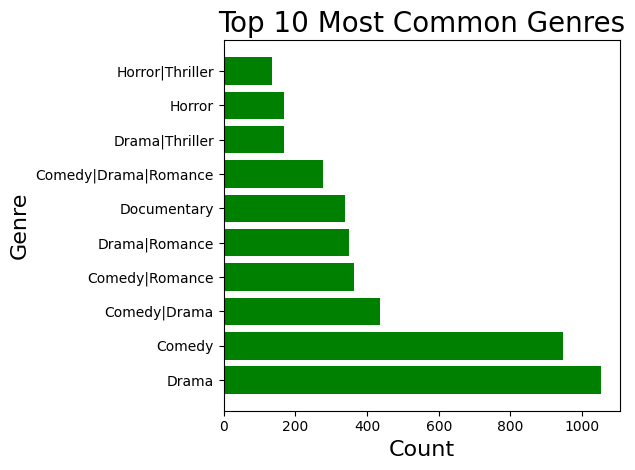

In [3]:
#Horizontal Bar Plot
#Shows the frequencies of genres in the dataset
genre_counts = Movies['genres'].value_counts().head(10)
import matplotlib.pyplot as plt
plt.barh(genre_counts.index, genre_counts.values, color='green')
plt.title('Top 10 Most Common Genres',fontsize=20)
plt.xlabel('Count',fontsize=16)
plt.ylabel('Genre',fontsize=16)
plt.tight_layout()
plt.show()

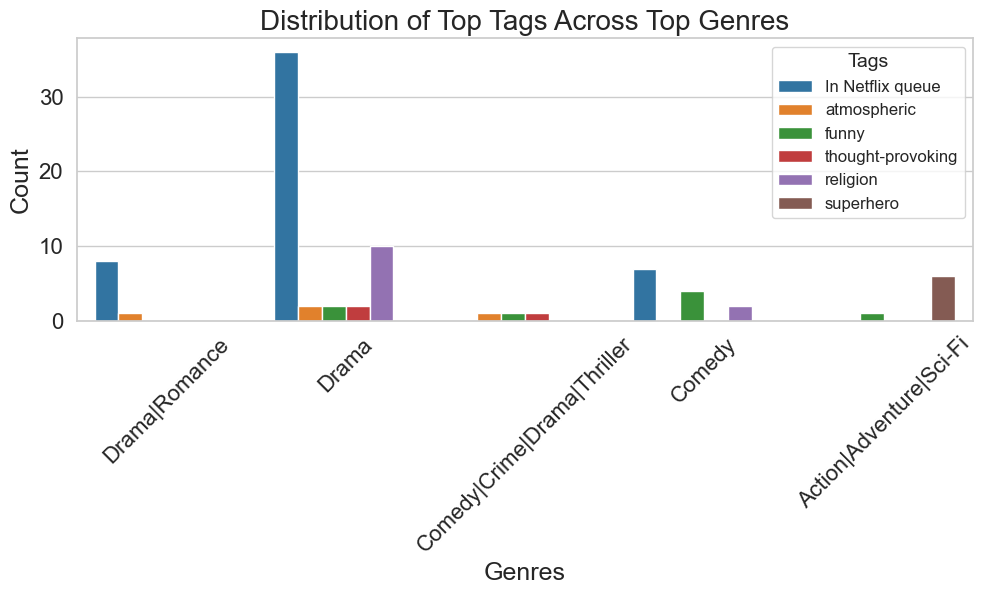

In [4]:
#Grouped Count Plot
#Distribution of Tags across Genres

#Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Merge the 2 columns from different files 
#For visualization to take place
merged_df = pd.merge(Movies, Tags, on='movieId')

#Top 5 genres and top 5 tags
top_genres = merged_df['genres'].value_counts().index[:5]
top_tags = merged_df['tag'].value_counts().index[:8]

#Filter the merged data
filtered_df = merged_df[
    (merged_df['genres'].isin(top_genres)) &
    (merged_df['tag'].isin(top_tags))
]

#Plot
plt.figure(figsize=(10, 6))  # Bigger figure = longer bars
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5)  # Bigger fonts
sns.countplot(data=filtered_df, x='genres', hue='tag', width=0.8)  # Wider bars
plt.title('Distribution of Top Tags Across Top Genres', fontsize=20)
plt.xlabel('Genres', fontsize=18)
plt.ylabel('Count', fontsize=18)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(title='Tags', fontsize=12, title_fontsize=14)
plt.tight_layout(pad=0.5)
plt.show()





In [5]:
print(Movies.columns)
print(Tags.columns)

Index(['movieId', 'title', 'genres'], dtype='object')
Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')
